In [1]:
import os
import sys
from pathlib import Path
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_NUM_INTRAOP_THREADS"] = "2"
os.environ["TF_NUM_INTEROP_THREADS"] = "2"
os.environ["OMP_NUM_THREADS"] = "2"
project_directory = Path.cwd()
if not (project_directory / "common.py").is_file():
    project_directory = project_directory.parent
sys.path.insert(0, str(project_directory))
from common import ROOT, MODE, SEED, BATCH, EPOCHS, CLASSES, ensure_data, split_paths, seed_all, load_array, evaluate_binary, save_metrics
seed_all()
print(f"Project: {ROOT.name} | mode: {MODE} | seed: {SEED}")


Project: land-classification-github | mode: quick | seed: 7331


In [2]:
import numpy as np
import tensorflow as tf
from common import DATA
train, val, test = split_paths()
print("Train / validation / test:", len(train[0]), len(val[0]), len(test[0]))
def batches(paths, labels, batch_size=8):
    for start in range(0, len(paths), batch_size):
        yield load_array(paths[start:start + batch_size]), labels[start:start + batch_size]
images, targets = next(batches(*train))
print("Custom generator:", images.shape, targets.tolist())


Train / validation / test: 336 72 72
Custom generator: (8, 64, 64, 3) [1, 1, 1, 0, 1, 1, 1, 0]


In [3]:
keras_ds = tf.keras.utils.image_dataset_from_directory(
    DATA, image_size=(64, 64), batch_size=8, shuffle=False
)
example_images, example_labels = next(iter(keras_ds.take(1)))
print("Keras ImageDataset:", example_images.shape, example_labels.numpy().tolist())
print("Class names:", keras_ds.class_names)


Found 6000 files belonging to 2 classes.
Keras ImageDataset: (8, 64, 64, 3) [0, 0, 0, 0, 0, 0, 0, 0]
Class names: ['class_0_non_agri', 'class_1_agri']


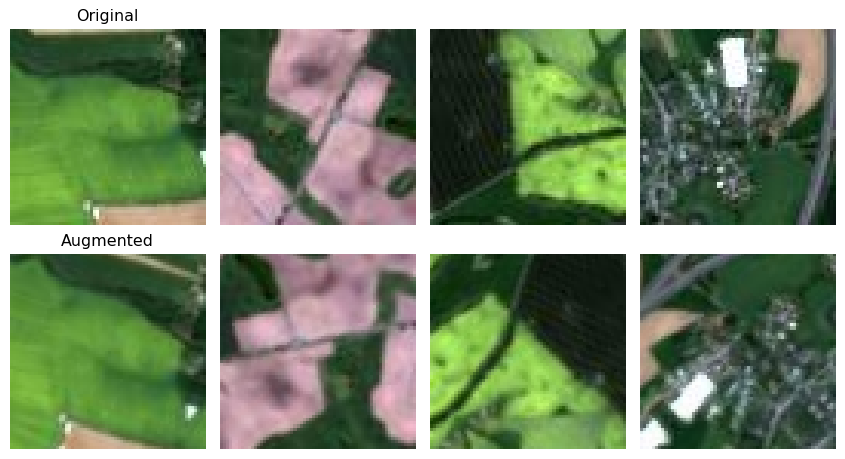

In [4]:
augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.15),
])
augmented = augmentation(images[:4], training=True)
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 4, figsize=(9, 5))
for index in range(4):
    axes[0, index].imshow(images[index])
    axes[1, index].imshow(np.clip(augmented[index].numpy(), 0, 1))
    for row in range(2):
        axes[row, index].axis("off")
axes[0, 0].set_title("Original")
axes[1, 0].set_title("Augmented")
plt.tight_layout()
plt.show()
